Import packages

In [128]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cobra
from cobra.io import read_sbml_model, write_sbml_model
from cobra.flux_analysis import flux_variability_analysis
from tqdm import tqdm

In [129]:
from pathlib import Path
import plotly
import plotly.express as px
import scipy.stats

os.environ["OMP_NUM_THREADS"] = "1"  # because of a data leak of KMeans on windows
import fba_comparison_stats as cmp
from efflux_method import *
import networkx as nx
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

Import the models

How to make each models, how to put information in it? Efflux?

In [200]:
M_xanthus = read_sbml_model("../M_xanthus_model_V5_5.xml")

In [131]:
#Add importation constraints
M_xanthus.reactions.EX_alaala_e.lower_bound = 0
M_xanthus.reactions.EX_glu_L_e.lower_bound = 0
M_xanthus.reactions.EX_his_L_e.lower_bound = 0
M_xanthus.reactions.EX_co2_e.lower_bound = 0
M_xanthus.reactions.EX_lys_L_e.lower_bound = 0
M_xanthus.reactions.EX_malt_e.lower_bound = 0
M_xanthus.reactions.EX_met_L_e.lower_bound = 0
M_xanthus.reactions.EX_pheme_e.lower_bound = 0
M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
M_xanthus.reactions.EX_orn_e.lower_bound = 0
M_xanthus.reactions.EX_ac_e.lower_bound = 0
M_xanthus.reactions.EX_fru_e.lower_bound = 0
M_xanthus.reactions.EX_for_e.lower_bound = 0

In [132]:
M_xanthus.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Fe3_e,EX_Fe3_e,0.3066,0,0.00%
ca2_e,EX_ca2_e,0.07665,0,0.00%
cl_e,EX_cl_e,0.07665,0,0.00%
cobalt2_e,EX_cobalt2_e,0.07665,0,0.00%
cu2_e,EX_cu2_e,0.07665,0,0.00%
hdca_e,EX_hdca_e,200.2,16,92.64%
ile_L_e,EX_ile_L_e,11.18,6,1.94%
k_e,EX_k_e,0.07665,0,0.00%
leu_L_e,EX_leu_L_e,17.36,6,3.01%
mg2_e,EX_mg2_e,0.07665,0,0.00%


In [133]:
list_of_genes = []
for i in M_xanthus.genes:
    list_of_genes.append(i.id)

In [201]:
# Getting fluxes with constrains
dico = {
    14: "Alone",
    2: "P_E_coli_1-3",
    5: "P_B_subtilis",
    8: "P_Caulobacter",
    20: "P_E_coli_1-1",
}
for i in [14, 2, 5, 8, 20]:
    M_xanthus = read_sbml_model("../M_xanthus_model_V5_5.xml")
    #Add importation constraints
    M_xanthus.reactions.EX_alaala_e.lower_bound = 0
    M_xanthus.reactions.EX_glu_L_e.lower_bound = 0
    M_xanthus.reactions.EX_his_L_e.lower_bound = 0
    M_xanthus.reactions.EX_co2_e.lower_bound = 0
    M_xanthus.reactions.EX_lys_L_e.lower_bound = 0
    M_xanthus.reactions.EX_malt_e.lower_bound = 0
    M_xanthus.reactions.EX_met_L_e.lower_bound = 0
    M_xanthus.reactions.EX_pheme_e.lower_bound = 0
    M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
    M_xanthus.reactions.EX_orn_e.lower_bound = 0
    M_xanthus.reactions.EX_ac_e.lower_bound = 0
    M_xanthus.reactions.EX_fru_e.lower_bound = 0
    M_xanthus.reactions.EX_for_e.lower_bound = 0
    M_xanthus.reactions.EX_gam_e.lower_bound = 0
    M_xanthus.reactions.EX_glc_D_e_lower_bound = 0
    M_xanthus.reactions.EX_malt_e_lower_bound = 0
    DictAP = read_csv_data(
        "/home/mickael/github/M_xanthus-E_coli-Predation/data/Raw/WT_vs_4preys_iMAT.csv",
        id_gene=1,
        id_val=i,
        list_of_genes=list_of_genes,
        head=True,
        quantile=0.95,
    )
    Eflux(M_xanthus, DictAP, const=100, default_exp_val=1, ignore_human=True)
    M_xanthus.reactions.EX_glc_D_e.bounds = (0, 1000)
    model_c = M_xanthus.copy()
    write_sbml_model(
        model_c,
        "/home/mickael/github/M_xanthus-E_coli-Predation/fba_comparer-main/Models_Preda/M_xanthus_V4_efflux_"
        + dico[i]
        + ".xml",
    )
    print(dico[i] + " Done!")

Alone Done!
P_E_coli_1-3 Done!
P_B_subtilis Done!
P_Caulobacter Done!
P_E_coli_1-1 Done!


In [202]:
M_xanthus_alone = read_sbml_model("Models_Preda/M_xanthus_V4_efflux_Alone.xml")
solution_alone = M_xanthus_alone.optimize()

In [203]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_E_coli_1-3.xml"
)
solution_predation_E_3 = M_xanthus_predation.optimize()

In [204]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_B_subtilis.xml"
)
solution_predation_B = M_xanthus_predation.optimize()

In [205]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_Caulobacter.xml"
)
solution_predation_C = M_xanthus_predation.optimize()

In [206]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_E_coli_1-1.xml"
)
solution_predation_E_1 = M_xanthus_predation.optimize()

In [207]:
print(f"Alone:\t{solution_alone.objective_value}")
print(f"Predation E.coli 1/1 :\t{solution_predation_E_1.objective_value}")
print(f"Predation E.coli 1/3 :\t{solution_predation_E_3.objective_value}")
print(f"Predation B_subtilis:\t{solution_predation_B.objective_value}")
print(f"Predation Caulobacter:\t{solution_predation_C.objective_value}")

Alone:	0.20445275853613412
Predation E.coli 1/1 :	0.16754778715563928
Predation E.coli 1/3 :	0.10165517381424213
Predation B_subtilis:	0.15158979104534825
Predation Caulobacter:	0.16752521568295795


## **FBA Comparer**
**Create combined dataframe and preprocess data**

Filter all reactions where fluxes are zero:

In [208]:
solutions = [
    solution_alone,
    solution_predation_E_1,
    solution_predation_E_3,
    solution_predation_B,
    solution_predation_C,
]
conditions = [
    "Alone",
    "Predation E.coli 1/1",
    "Predation E.coli 1/3",
    "Predation B. subtilis",
    "Predation Caulobacter",
]
obj_values = [
    solution_alone.objective_value,
    solution_predation_E_1.objective_value,
    solution_predation_E_3.objective_value,
    solution_predation_B.objective_value,
    solution_predation_C.objective_value,
]

mxanthus = cmp.build_dataframe(M_xanthus_alone, solutions, conditions)
mxanthus_filtered = cmp.filter_dataframe(mxanthus, conditions, rounding=True)
print(f"Number of reactions in the models: {len(mxanthus)}")
print(f"Number of nonzero reactions in the models: {len(mxanthus_filtered)}")

Number of reactions in the models: 1339
Number of nonzero reactions in the models: 492


normalize data:

In [209]:
mxanthus_normalized = cmp.normalize_dataframe_cols(
    mxanthus_filtered, conditions, obj_values
)  # biomass normalization
mxanthus_normalized_div_by_max = cmp.normalize_dataframe_rows(
    mxanthus_normalized, conditions, "div_by_max"
)  # normalization reactions
# note: there is no difference between the order of div_by_max normalization and filtering for changing reactions
mxanthus_normalized_div_by_max_changing = mxanthus_normalized_div_by_max[
    mxanthus_normalized_div_by_max["Std_dev"] >= 0.01
]  # keep only reactions that change
print(
    f"Number of normalized changing reactions: {len(mxanthus_normalized_div_by_max_changing)}"
)

Number of normalized changing reactions: 190


## Identify reactions with most/least variation

Most affected / change reaction

In [143]:
M_xanthus.reactions.rxn01444_c

Reaction identifier,rxn01444_c
Name,ATP:deoxyguanosine 5'-phosphotransferase [c]
Memory address,0x70d7f674d8b0
Stoichiometry,atp_c + dgsn_c --> adp_c + dgmp_c + h_c ATP [c] + Deoxyguanosine [c] --> ADP [c] + dGMP [c] + H+ [c]
GPR,(MXAN_3331 and MXAN_2054 and MXAN_2591) or (MXAN_3331 and MXAN_2054 and MXAN_2591)
Lower bound,0
Upper bound,17.21363414645268


In [210]:
most_variable_bar_plot = cmp.bar_plot_flux_variation(
    mxanthus_normalized, conditions, 0, 10
)
most_variable_bar_plot.show()

In [211]:
sorted_flux = mxanthus_normalized[["ID", "Name", "Std_dev"]].sort_values(
    by=["Std_dev"], ascending=False
)
sorted_flux["Kegg"] = [
    M_xanthus_alone.reactions.get_by_id(id).__dict__["_annotation"].get("kegg.reaction")
    for id in sorted_flux["ID"]
]
sorted_flux[0:10]

,ID,Name,Std_dev,Kegg
1109,rxn08173_c,F(1)-ATPase [c],6.086672,None
1101,rxn14419_c,cytochrome-bd oxidase (2 protons translocated)...,4.685479,None
1261,EX_pi_e,Exchange for Phosphate [e],4.669797,None
672,rxn05312_c,Inorganic phosphate transporter [c],4.669797,None
147,rxn00148_c,ATP:pyruvate 2-O-phosphotransferase [c],4.240304,R00200
1093,rxn00154_c,pyruvate:NAD+ 2-oxidoreductase (CoA-acetylatin...,4.239451,R00209
1288,EX_co2_e,Exchange for CO2 [e],4.201104,None
1187,rxn05467_c,CO2 transporter via diffusion [c],4.201104,None
1276,EX_h2o_e,Exchange for H2O [e],3.963183,None
158,rxn05319_c,TRANS-RXNBWI-115401.ce.maizeexp.OH_OH [c],3.963183,None


In [290]:
M_xanthus.reactions.rxn14419_c

Reaction identifier,rxn14419_c
Name,cytochrome-bd oxidase (2 protons translocated) [c]
Memory address,0x70d7f7417da0
Stoichiometry,cytochrome_bd_red_c + 4.0 h_c + 0.5 o2_c --> cytochrome_bd_ox_c + h2o_c + 2.0 h_e Cytochrome-bd-red [c] + 4.0 H+ [c] + 0.5 O2 [c] --> Cytochrome-bd-ox [c] + H2O [c] + 2.0 H+ [e]
GPR,MXAN_6913 and MXAN_6912
Lower bound,0
Upper bound,1.3584912541427168


In [217]:
M_xanthus.reactions.rxn00154_c

Reaction identifier,rxn00154_c
Name,pyruvate:NAD+ 2-oxidoreductase (CoA-acetylating) [c]
Memory address,0x70d7f7417290
Stoichiometry,coa_c + nad_c + pyr_c --> accoa_c + co2_c + nadh_c CoA [c] + NAD [c] + Pyruvate [c] --> Acetyl-CoA [c] + CO2 [c] + NADH [c]
GPR,MXAN_4219 and MXAN_2668 and MXAN_2667 and MXAN_1924 and MXAN_2666
Lower bound,0
Upper bound,19.137403640574245


In [218]:
M_xanthus.metabolites.pyr_c.summary()

Percent,Flux,Reaction,Definition
99.06%,1.167,rxn00148_c,atp_c + pyr_c <=> adp_c + h_c + pep_c
0.65%,0.007633,rxn00726_c,chor_c + nh4_c --> anth_c + h2o_c + h_c + pyr_c
0.09%,0.001053,rxn00840_c,datp_c + pyr_c <=> dadp_c + h_c + pep_c
0.09%,0.001053,rxn01354_c,dgtp_c + pyr_c <=> dgdp_c + h_c + pep_c
0.07%,0.0008042,rxn03841_c,4adcho_c --> 4abz_c + h_c + pyr_c
0.05%,0.0005362,rxn11703_c,2_Succinyl_5_enolpyruvyl_6_hydroxy_3_cyclohexene_1_carboxylate_c --> 2shchc_c + pyr_c
Percent,Flux,Reaction,Definition
88.38%,-1.041,rxn00154_c,coa_c + nad_c + pyr_c --> accoa_c + co2_c + nadh_c
7.22%,-0.08506,rxn00278_c,ala_L_c + h2o_c + nad_c <=> h_c + nadh_c + nh4_c + pyr_c
0.02%,-0.0002681,rxn03909_c,g3p_c + h_c + pyr_c --> co2_c + dxyl5p_c


In [219]:
from bioservices import KEGG

k = KEGG()

for rxn in M_xanthus.reactions:
    if "kegg.reaction" in rxn.annotation:
        kegg_id = rxn.annotation["kegg.reaction"]
        try:
            data = k.get(kegg_id)
            parsed = k.parse(data)
            if "PATHWAY" in parsed:
                rxn.subsystem = list(parsed["PATHWAY"].values())[0]
        except:
            continue

WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02371)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R01549)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02097)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02292)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R00962)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R00967)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https

**LOOKING STUFF**

In [220]:
liste = []
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Glycolysis / Gluconeogenesis":
        liste.append(i)

sorted_flux.loc[sorted_flux["ID"].isin(liste)]

,ID,Name,Std_dev,Kegg
147,rxn00148_c,ATP:pyruvate 2-O-phosphotransferase [c],4.240304,R00200
531,rxn01106_c,"2-Phospho-D-glycerate 2,3-phosphomutase [c]",3.819234,R01518
700,rxn00459_c,2-phospho-D-glycerate hydro-lyase (phosphoenol...,3.819234,R00658
157,rxn00781_c,D-glyceraldehyde-3-phosphate:NAD+ oxidoreducta...,3.816472,R01061
417,rxn01100_c,ATP:3-phospho-D-glycerate 1-phosphotransferase...,3.816472,R01512
298,rxn00747_c,D-glyceraldehyde-3-phosphate aldose-ketose-iso...,3.815609,R01015
32,rxn00172_c,Acetate:CoA ligase (ADP-forming) [c],0.490884,R00229
414,rxn00786_c,"D-fructose-1,6-bisphosphate D-glyceraldehyde-3...",0.055446,R01068
203,rxn00549_c,"D-Fructose-1,6-bisphosphate 1-phosphohydrolase...",0.055446,R00762


Pathway analysis

In [221]:
mxanthus_normalized.loc[mxanthus_normalized["ID"].isin(liste)] #Glycolysis / Gluconeogenesis

,ID,Reaction,Name,Alone,Predation E.coli 1/1,Predation E.coli 1/3,Predation B. subtilis,Predation Caulobacter,Std_dev,Mean
32,rxn00172_c,rxn00172_c: ac_c + atp_c + coa_c <=> accoa_c +...,Acetate:CoA ligase (ADP-forming) [c],-12.229932,-11.687036,-12.835856,-12.656550,-12.826585,0.490884,-12.447192
147,rxn00148_c,rxn00148_c: atp_c + pyr_c <=> adp_c + h_c + pep_c,ATP:pyruvate 2-O-phosphotransferase [c],-6.894441,-0.760084,-0.763284,-8.374930,-9.628038,4.240304,-5.284155
157,rxn00781_c,rxn00781_c: g3p_c + nad_c + pi_c <=> 13dpg_c +...,D-glyceraldehyde-3-phosphate:NAD+ oxidoreducta...,7.163283,1.504260,1.532825,9.112706,8.788090,3.816472,5.620233
203,rxn00549_c,rxn00549_c: fdp_c + h2o_c --> f6p_c + pi_c,"D-Fructose-1,6-bisphosphate 1-phosphohydrolase...",0.651545,0.752775,0.752775,0.651545,0.651545,0.055446,0.692037
298,rxn00747_c,rxn00747_c: g3p_c <=> dhap_c,D-glyceraldehyde-3-phosphate aldose-ketose-iso...,-8.192869,-2.537046,-2.562411,-10.142292,-9.817676,3.815609,-6.650459
414,rxn00786_c,rxn00786_c: fdp_c <=> dhap_c + g3p_c,"D-fructose-1,6-bisphosphate D-glyceraldehyde-3...",-0.651545,-0.752775,-0.752775,-0.651545,-0.651545,0.055446,-0.692037
417,rxn01100_c,rxn01100_c: 3pg_c + atp_c <=> 13dpg_c + adp_c,ATP:3-phospho-D-glycerate 1-phosphotransferase...,-7.163283,-1.504260,-1.532825,-9.112706,-8.788090,3.816472,-5.620233
531,rxn01106_c,rxn01106_c: 2pg_c <=> 3pg_c,"2-Phospho-D-glycerate 2,3-phosphomutase [c]",-7.105587,-1.504260,-1.501060,-9.112706,-8.788090,3.819234,-5.602340
700,rxn00459_c,rxn00459_c: 2pg_c <=> h2o_c + pep_c,2-phospho-D-glycerate hydro-lyase (phosphoenol...,7.105587,1.504260,1.501060,9.112706,8.788090,3.819234,5.602340


In [222]:
M_xanthus_alone.reactions.rxn00459_c.flux

1.4527568393042263

In [223]:
M_xanthus_alone.metabolites.damp_c.summary()

Percent,Flux,Reaction,Definition
Percent,Flux,Reaction,Definition


In [224]:
M_xanthus_alone.metabolites.dgdp_c.summary()

Percent,Flux,Reaction,Definition
100.00%,0.001285,rxn05233_c,gdp_c + trdrd_c --> dgdp_c + h2o_c + trdox_c
Percent,Flux,Reaction,Definition
100.00%,-0.001285,rxn01354_c,dgtp_c + pyr_c <=> dgdp_c + h_c + pep_c


In [225]:
liste = []
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Citrate cycle (TCA cycle)":
        liste.append(i)

sorted_flux.loc[sorted_flux["ID"].isin(liste)]

,ID,Name,Std_dev,Kegg
363,rxn00285_c,Succinate:CoA ligase (ADP-forming) [c],2.240374,R00405
846,rxn01388_c,isocitrate hydro-lyase (cis-aconitate-forming)...,1.180062,R01900
919,rxn00974_c,citrate hydro-lyase (cis-aconitate-forming) [c],1.180062,R01325
961,rxn00256_c,acetyl-CoA:oxaloacetate C-acetyltransferase (t...,1.180062,R00351
653,rxn00799_c,(S)-malate hydro-lyase (fumarate-forming) [c],0.897091,R01082
734,rxn01387_c,Isocitrate:NADP+ oxidoreductase [c],0.415083,R01899
26,rxn00199_c,oxalosuccinate carboxy-lyase (2-oxoglutarate-f...,0.415083,R00268
287,rxn00248_c,(S)-malate:NAD+ oxidoreductase [c],0.212833,R00342
284,rxn01872_c,succinyl-CoA:enzyme N6-(dihydrolipoyl)lysine S...,0.008000,R02570
121,rxn02376_c,R03316 [c],0.008000,R03316


In [226]:
mxanthus_normalized.loc[mxanthus_normalized["ID"].isin(liste)] #TCA Cycle

,ID,Reaction,Name,Alone,Predation E.coli 1/1,Predation E.coli 1/3,Predation B. subtilis,Predation Caulobacter,Std_dev,Mean
26,rxn00199_c,rxn00199_c: h_c + oxasucc_c --> akg_c + co2_c,oxalosuccinate carboxy-lyase (2-oxoglutarate-f...,0.907832,1.836121,1.371436,0.907832,0.907832,0.415083,1.186211
121,rxn02376_c,rxn02376_c: 3_Carboxy_1_hydroxypropyl_ThPP_c +...,R03316 [c],0.000000,0.017889,0.000000,0.000000,0.000000,0.008000,0.003578
284,rxn01872_c,rxn01872_c: dhlam_c + succoa_c <=> coa_c + sdh...,succinyl-CoA:enzyme N6-(dihydrolipoyl)lysine S...,0.000000,-0.017889,0.000000,0.000000,0.000000,0.008000,-0.003578
287,rxn00248_c,rxn00248_c: mal_L_c + nad_c <=> h_c + nadh_c +...,(S)-malate:NAD+ oxidoreductase [c],0.000000,0.000000,0.000000,-0.475910,0.000000,0.212833,-0.095182
363,rxn00285_c,rxn00285_c: atp_c + coa_c + succ_c <=> adp_c +...,Succinate:CoA ligase (ADP-forming) [c],0.000000,0.000000,0.000000,4.390302,3.748291,2.240374,1.627719
653,rxn00799_c,rxn00799_c: mal_L_c <=> fum_c + h2o_c,(S)-malate hydro-lyase (fumarate-forming) [c],-3.641730,-4.135666,-3.963906,-2.789090,-1.995278,0.897091,-3.305134
734,rxn01387_c,rxn01387_c: icit_c + nadp_c <=> h_c + nadph_c ...,Isocitrate:NADP+ oxidoreductase [c],0.907832,1.836121,1.371436,0.907832,0.907832,0.415083,1.186211
846,rxn01388_c,rxn01388_c: icit_c <=> acon_C_c + h2o_c,isocitrate hydro-lyase (cis-aconitate-forming)...,3.894775,2.980300,2.597270,4.133431,5.628254,1.180062,3.846806
919,rxn00974_c,rxn00974_c: cit_c <=> acon_C_c + h2o_c,citrate hydro-lyase (cis-aconitate-forming) [c],-3.894775,-2.980300,-2.597270,-4.133431,-5.628254,1.180062,-3.846806
961,rxn00256_c,rxn00256_c: cit_c + coa_c + h_c <=> accoa_c + ...,acetyl-CoA:oxaloacetate C-acetyltransferase (t...,3.894775,2.980300,2.597270,4.133431,5.628254,1.180062,3.846806


In [227]:
liste = []
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Pyrimidine metabolism":
        liste.append(i)

filter = sorted_flux.loc[sorted_flux["ID"].isin(liste)][0:4]["ID"]
sorted_flux.loc[sorted_flux["ID"].isin(liste)]

,ID,Name,Std_dev,Kegg
1025,rxn01513_c,ATP:dTMP phosphotransferase [c],6.838624e-01,R02094
762,rxn01512_c,ATP:dTDP phosphotransferase [c],6.838624e-01,R02093
716,rxn01366_c,Uridine:phosphate alpha-D-ribosyltransferase [c],6.134649e-03,R01876
526,rxn01678_c,ATP:dUDP phosphotransferase [c],6.134649e-03,R02331
499,rxn00711_c,UMP:diphosphate phospho-alpha-D-ribosyltransfe...,6.134649e-03,R00966
1069,rxn01520_c,"5,10-Methylenetetrahydrofolate:dUMP C-methyltr...",6.134649e-03,R02101
360,rxn01146_c,thymidine:phosphate deoxy-alpha-D-ribosyltrans...,6.134649e-03,R01570
452,rxn01145_c,Thymidylate 5'-phosphohydrolase [c],6.134649e-03,R01569
375,rxn01518_c,ATP:deoxyuridine 5'-phosphotransferase [c],6.134649e-03,R02099
977,rxn01799_c,deoxyuridine:orthophosphate 2-deoxy-D-ribosylt...,6.134649e-03,R02484


In [228]:
mxanthus_normalized.loc[mxanthus_normalized["ID"].isin(filter)] #Pyrimidine

,ID,Reaction,Name,Alone,Predation E.coli 1/1,Predation E.coli 1/3,Predation B. subtilis,Predation Caulobacter,Std_dev,Mean
526,rxn01678_c,rxn01678_c: atp_c + dudp_c <=> adp_c + dutp_c,ATP:dUDP phosphotransferase [c],-0.078139,-0.066939,-0.066939,-0.078139,-0.078139,0.006135,-0.073659
716,rxn01366_c,rxn01366_c: pi_c + uri_c <=> r1p_c + ura_c,Uridine:phosphate alpha-D-ribosyltransferase [c],0.084425,0.073225,0.073225,0.084425,0.084425,0.006135,0.079945
762,rxn01512_c,rxn01512_c: atp_c + dtdp_c <=> adp_c + dttp_c,ATP:dTDP phosphotransferase [c],-2.906807,-4.710929,-4.195359,-3.937003,-3.513762,0.683862,-3.852772
1025,rxn01513_c,rxn01513_c: atp_c + dtmp_c + h_c <=> adp_c + d...,ATP:dTMP phosphotransferase [c],-3.202211,-5.006333,-4.490763,-4.232407,-3.809166,0.683862,-4.148176


In [229]:
M_xanthus.reactions.rxn00711_c

Reaction identifier,rxn00711_c
Name,UMP:diphosphate phospho-alpha-D-ribosyltransferase [c]
Memory address,0x70d7f8970620
Stoichiometry,h_c + ppi_c + ump_c <=> prpp_c + ura_c H+ [c] + PPi [c] + UMP [c] <=> PRPP [c] + Uracil [c]
GPR,MXAN_0124
Lower bound,-15.93719941101657
Upper bound,15.93719941101657


In [230]:
M_xanthus.metabolites.get_by_id("pep_c").summary()

Percent,Flux,Reaction,Definition
75.86%,0.9807,rxn00251_c,h_c + oaa_c + pi_c <=> co2_c + h2o_c + pep_c
24.14%,0.3121,rxn00459_c,2pg_c <=> h2o_c + pep_c
Percent,Flux,Reaction,Definition
90.28%,-1.167,rxn00148_c,atp_c + pyr_c <=> adp_c + h_c + pep_c
0.42%,-0.005375,rxn00461_c,pep_c + uacgam_c --> pi_c + uaccg_c
0.08%,-0.001053,rxn00840_c,datp_c + pyr_c <=> dadp_c + h_c + pep_c
4.16%,-0.05374,rxn01332_c,e4p_c + h2o_c + pep_c --> 2dda7p_c + pi_c
0.08%,-0.001053,rxn01354_c,dgtp_c + pyr_c <=> dgdp_c + h_c + pep_c
0.83%,-0.01075,rxn02331_c,kdo8p_c + pi_c <=> ara5p_c + h2o_c + pep_c
4.16%,-0.05374,rxn02476_c,pep_c + skm5p_c <=> 3psme_c + pi_c


**Pathway analysis**

In [231]:
M_xanthus.metabolites.uacgam_c.summary()

Percent,Flux,Reaction,Definition
100.00%,0.0215,rxn00293_c,acgam1p_c + h_c + utp_c --> ppi_c + uacgam_c
Percent,Flux,Reaction,Definition
25.00%,-0.005375,rxn00461_c,pep_c + uacgam_c --> pi_c + uaccg_c
25.00%,-0.005375,rxn03408_c,uacgam_c + uagmda_c --> h_c + uaagmda_c + udp_c
50.00%,-0.01075,rxn06729_c,3htdACP_c + uacgam_c <=> ACP_c + u3aga_c


In [232]:
pathway_dict_M = {}
for i in M_xanthus.reactions:
    if i.subsystem in pathway_dict_M:
        pathway_dict_M[i.subsystem].append(i.id)
    else:
        pathway_dict_M[i.subsystem] = [i.id]

In [233]:
pw_list = cmp.pathway_variability(
    mxanthus_normalized, pathway_dict_M, ascending=True, num=10
)

Metabolic pathways		 -> 4.24 (contains 1 reactions)
Glycerophospholipid metabolism		 -> 3.76 (contains 1 reactions)
Glycolysis / Gluconeogenesis		 -> 2.66 (contains 9 reactions)
Valine, leucine and isoleucine degradation		 -> 1.14 (contains 6 reactions)
Arginine biosynthesis		 -> 0.92 (contains 8 reactions)
Pyruvate metabolism		 -> 0.77 (contains 2 reactions)
Fatty acid elongation		 -> 0.71 (contains 19 reactions)
Citrate cycle (TCA cycle)		 -> 0.70 (contains 11 reactions)
		 -> 0.60 (contains 173 reactions)
Glyoxylate and dicarboxylate metabolism		 -> 0.58 (contains 3 reactions)


In [234]:
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Glycolysis / Gluconeogenesis":
        print(i)

rxn02342_c
rxn00172_c
rxn00545_c
rxn00148_c
rxn00781_c
rxn00549_c
rxn00506_c
rxn00305_c
rxn00747_c
rxn00147_c
rxn01871_c
rxn00786_c
rxn01100_c
rxn01106_c
rxn00543_c
rxn00011_c
rxn00459_c
rxn00175_c
rxn01171_c
rxn15249_c
rxn20583_c


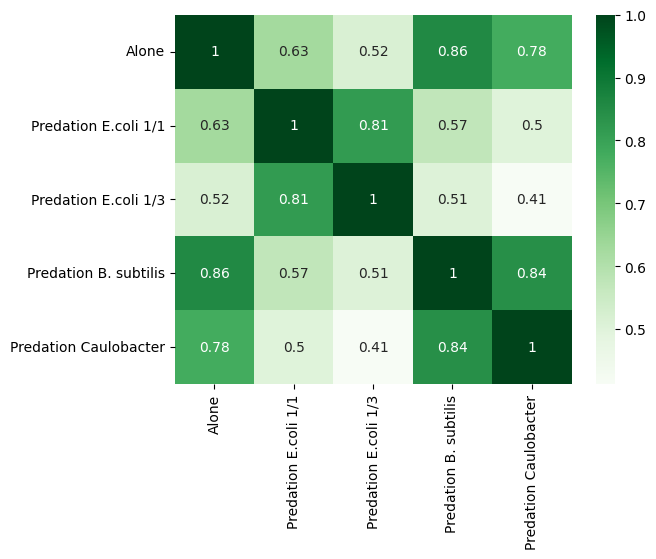

In [235]:
fig_r = cmp.correlation_matrix(
    mxanthus_normalized_div_by_max_changing, conditions, color="Greens"
)

## Flux correlation network

In [236]:
import seaborn as sns
import matplotlib.pyplot as plt

In [237]:
corr_matrix = cmp.flux_coupling_matrix(
    mxanthus_normalized_div_by_max, conditions, remove_unchanging=0.01, abs_values=True
)

302 reaction were removed, because their Std_dev is lower than 0.01
The following 4 reactions were removed because they swap signs across conditions: ['rxn05319_c', 'rxn00178_c', 'rxn08527_c', 'EX_h2o_e']


In [238]:
mask = []
for i in corr_matrix:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Purine metabolism":
        mask.append(i)

new = corr_matrix.filter(mask, axis=0)
corr_matrix_filter = new.filter(mask, axis=1)

corr_matrix_filter

,rxn00836_c,rxn00800_c,rxn00097_c,rxn00139_c,rxn00237_c,rxn00838_c,rxn00379_c,rxn01859_c,rxn01985_c,rxn01858_c
rxn00836_c,1.000000,-1.000000,0.618752,0.998272,-1.000000,-1.000000,-0.391591,0.999968,0.999968,0.999968
rxn00800_c,-1.000000,1.000000,-0.618752,-0.998272,1.000000,1.000000,0.391591,-0.999968,-0.999968,-0.999968
rxn00097_c,0.618752,-0.618752,1.000000,0.662442,-0.618752,-0.618752,0.216279,0.619344,0.619344,0.619344
rxn00139_c,0.998272,-0.998272,0.662442,1.000000,-0.998272,-0.998272,-0.354892,0.998398,0.998398,0.998398
rxn00237_c,-1.000000,1.000000,-0.618752,-0.998272,1.000000,1.000000,0.391591,-0.999968,-0.999968,-0.999968
rxn00838_c,-1.000000,1.000000,-0.618752,-0.998272,1.000000,1.000000,0.391591,-0.999968,-0.999968,-0.999968
rxn00379_c,-0.391591,0.391591,0.216279,-0.354892,0.391591,0.391591,1.000000,-0.388663,-0.388663,-0.388663
rxn01859_c,0.999968,-0.999968,0.619344,0.998398,-0.999968,-0.999968,-0.388663,1.000000,1.000000,1.000000
rxn01985_c,0.999968,-0.999968,0.619344,0.998398,-0.999968,-0.999968,-0.388663,1.000000,1.000000,1.000000
rxn01858_c,0.999968,-0.999968,0.619344,0.998398,-0.999968,-0.999968,-0.388663,1.000000,1.000000,1.000000


In [239]:
# plt.figure(figsize=(16,12))
# sns.heatmap(corr_matrix_filter, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# plt.title("Correlation Heatmap")
# plt.show()

In [270]:
# Correlation network
nw = cmp.flux_coupling_network(corr_matrix, pc=0.7)
fig = cmp.visualize_interactive_network(nw, mxanthus_normalized_div_by_max, conditions)
fig.show()

Created Flux Coupling network with pc threshold 0.7.
Number of nodes: 186
Number of edges: 3741
Number of connected components: 2


In [271]:
# # Colored pathway network
# nw3 = nw
# cmp.color_network_by_pathway(
#     nw3, pathway= "Purine metabolism", pathway_dict= pathway_dict_M
# )  # takes edge weights into account!

# fig = cmp.visualize_interactive_network(nw3, mxanthus_normalized_div_by_max, conditions)
# fig.show()

In [272]:
# Colored community network
nw2 = nw
cmp.color_network_by_communities(
    nw2, 8, include_weights=True
)  # takes edge weights into account!

comm_map = cmp.get_community_list(nw)
color = cmp.get_color_map(comm_map)

fig = cmp.visualize_interactive_network(nw2, mxanthus_normalized_div_by_max, conditions)
fig.show()

Community map

In [273]:
fig = cmp.community_bar_plots(mxanthus_normalized_div_by_max, conditions, comm_map)
fig.show()

In [274]:
fig = cmp.community_box_plots(mxanthus_normalized_div_by_max, conditions, comm_map)
fig.show()

In [275]:
with open("pathway_information/mxanthus_filtered_ids.tsv", "w") as file:
    for line in M_xanthus.reactions:
        file.write(line.id + "\n")

In [276]:
## load ID dictionary (mapping ids to pathways)
filtered_ids = []
with open("pathway_information/mxanthus_filtered_ids.tsv", "r") as file:
    for line in file:
        filtered_ids.append(line.strip())
id_dict = {}
with open("pathway_information/ecoli_map_id_to_pathway.tsv", "r") as file: #TODO REDO THIS FILE FOR MYXO / line correspond to mxanthus_filtered_ids
    for id, line in zip(filtered_ids, file):
        if line == "\n":
            continue
        words = line.strip().split("\t")
        id_dict[id] = words

pathway_hierarchy = {}
with open("pathway_information/kegg_pathway_hierarchy.txt", "r") as file:
    for line in file:
        line = line.rstrip("\n")
        words = line.replace("_", " ").split("\\t")
        pathway_hierarchy[words.pop(0)] = words

In [277]:
# sankey diagram of KEGG pathway categories
fig = cmp.community_sankey_diagram(
    comm_map,
    list(pathway_hierarchy.keys()),
    mxanthus_normalized_div_by_max,
    id_dict,
    diagram_height=1000,
    pw_hierarchy=pathway_hierarchy,
    text_size=16,
)
fig.show()

Look for community 1, 2 and 3

Try also for 7 and 10

In [278]:
for i in comm_map:
    print(i)

#FD3216
#00FE35
#6A76FC
#FED4C4
#FE00CE
#0DF9FF
#F6F926
#FF9616
#479B55
#EEA6FB


In [279]:
# Community 1
Genes_list_1 = []
for i in comm_map["#FD3216"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_1:
            Genes_list_1.append(str(j))

with open('Genes_list_1.txt', 'w') as f:
    for line in Genes_list_1:
        f.write(f"{line}\n")

In [280]:
# Community 2
Genes_list_2 = []
for i in comm_map["#00FE35"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_2:
            Genes_list_2.append(str(j))

with open('Genes_list_2.txt', 'w') as f:
    for line in Genes_list_2:
        f.write(f"{line}\n")

In [281]:
# Community 3
Genes_list_3 = []
for i in comm_map["#6A76FC"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_3:
            Genes_list_3.append(str(j))

with open('Genes_list_3.txt', 'w') as f:
    for line in Genes_list_3:
        f.write(f"{line}\n")

In [282]:
# Community 4
Genes_list_4 = []
for i in comm_map["#FED4C4"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_4:
            Genes_list_4.append(str(j))

with open('Genes_list_4.txt', 'w') as f:
    for line in Genes_list_4:
        f.write(f"{line}\n")

In [283]:
# Community 5
Genes_list_5 = []
for i in comm_map["#FE00CE"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_5:
            Genes_list_5.append(str(j))

with open('Genes_list_5.txt', 'w') as f:
    for line in Genes_list_5:
        f.write(f"{line}\n")

In [284]:
# Community 6 #TODO REDO IT
Genes_list_6 = []
for i in comm_map["#0DF9FF"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_6:
            Genes_list_6.append(str(j))

with open('Genes_list_6.txt', 'w') as f:
    for line in Genes_list_6:
        f.write(f"{line}\n")